In [35]:
import numpy as np 
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

In [36]:
raw_base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/hcp_schaefer_100")
preprocessed_base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100")
preprocessed_base_path.mkdir(parents=True, exist_ok=True)


data = h5py.File(
   raw_base_path / "DTI_fibers_VolNorm_HCP.mat",
)

N_regions = 100
N_subjects = 100
connectomes = np.zeros((N_regions,N_regions,N_subjects))
for subject in range(N_subjects):
    ref = data["DTI_fibers_VolNorm_HCP"][0][subject]
    connectomes[...,subject]=data[ref][()]

connectomes = connectomes.T # Transpose to have shape (subjects, regions, regions) == (n_subj, 100, 100)
coordinates = np.loadtxt(raw_base_path / f"Schaefer_100_MNI_coords.txt") # (100, 5)
coordinates = coordinates[:, :3]  # Keep only 3D columns

In [37]:
# Get distance matrix 

from scipy.spatial.distance import cdist

distance_matrix = cdist(coordinates, coordinates)
np.fill_diagonal(distance_matrix, 0) # np.inf)

distance_matrix_path = preprocessed_base_path / "02_distance_matrices"
distance_matrix_path.mkdir(parents=True, exist_ok=True)

np.save(distance_matrix_path / "distance_matrix_100.npy", distance_matrix)

In [38]:

from __future__ import annotations

import argparse
import sys
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import bct
from netneurotools.networks import threshold_network, struct_consensus
from scipy.spatial.distance import cdist



import networkx as nx
import numpy as np
from scipy.spatial.distance import pdist, squareform

import networkx as nx
import numpy as np

# Local imports from your codebase
# from notebook_setup import setup
from preprocessing.get_distance_matrix import get_distance_matrix_from_coords, get_distance_matrix_from_fiber_lengths
from analysis.structural_measures import analyze_connectomes

from src.preprocessing.preprocessing_setup import setup
from preprocessing.threshold_to_density import threshold_to_density


from src.preprocessing.utils import setup_paths, ensure_dir, save_numpy, save_dataframe # TODO: Remove this again, not needed. 
# ----------------------------
# Config & argument parsing
# ----------------------------
# @dataclass
# class PipelineConfig:
#     resolution: int = 68
#     goal_densities: Tuple[int, ...] = (10, 12, 14, 16, 18, 20)  # in percent
#     analyze_density: int = 10  # used for steps requiring a single binarized set
#     do_plots: bool = False # True

#     # Communication model and rich-club options for graph measures
#     comm_mode: str = "estrada_scaled"
#     rich_nodes_global: Optional[np.ndarray] = None
#     rich_top_percent: float = 0.20



# def parse_args() -> PipelineConfig:
#     p = argparse.ArgumentParser(description="Connectome preprocessing pipeline")
    
#     TARGET_TOTAL_NUMBER_OF_NODES = 50 # CHANGE THIS HERE
        
#     p.add_argument("--resolution", type=int, default=TARGET_TOTAL_NUMBER_OF_NODES, # CHANGE here
#                    help="Parcellation resolution for distance matrix & inputs (default: 68)")
#     p.add_argument("--goal-densities", type=int, nargs="+",
#                    default=[10, 12, 14, 16, 18, 20],
#                    help="One or more goal densities in PERCENT to retain during thresholding")
#     p.add_argument("--analyze-density", type=int, default=10,
#                    help="Which density (in percent) to use for analyses that require a single binarized set")
#     p.add_argument("--do_plots", action="store_true",
#                    help="Activate plotting (only save data)")
#     p.add_argument("--comm-mode", type=str, default="estrada_scaled",
#                    help="Communication model used in analyze_connectomes (default: estrada_scaled)")
#     p.add_argument("--rich-top-percent", type=float, default=0.20,
#                    help="Top fraction for rich club node selection (default: 0.20)")

#     args = p.parse_args()

#     return PipelineConfig(
#         resolution=args.resolution,
#         goal_densities=tuple(args.goal_densities),
#         analyze_density=args.analyze_density,
#         do_plots=args.do_plots,
#         comm_mode=args.comm_mode,
#         rich_top_percent=args.rich_top_percent,
#     )

# # def main(resolution = None):
# # cfg = parse_args()

goal_density = 10 
resolution = 100 
# cfg = PipelineConfig(
#         resolution=50, # args.resolution, # CHANGE THIS HERE ?
#         goal_densities=[10], # tuple(args.goal_densities),
#         analyze_density=10, # args.analyze_density,
#         do_plots=True, # args.do_plots,
#         comm_mode="estrada_scaled", # args.comm_mode,
#         rich_top_percent=0.2) 


# paths = setup_paths(dataset_name="suarez_MaMI_dataset") 



# # Setup paths
# base_path = paths["path_raw_data"] / "connectivity/mami"
# conn_dir = base_path / "conn_100"
# coords_dir = base_path / "coords"

# resolution = 50 # final resolution (if this is 100 <-> 50 nodes PER SIDE)

# # Intermediate paths 
# output_conn_dir = paths["path_00_preprocessed"] / f"connectomes_downsampled_to_{resolution}" # per SIDE -> so a total of 100. 
# output_coords_dir = paths["path_00_preprocessed"] / f"coords_downsampled_to_{resolution}"
# output_results_dir = paths["path_output_for_logs_and_plots"] / "results"
# output_distance_matr_resampled_dir = paths["path_00_preprocessed"] / f"dis_matrices_downsampled_to_{resolution}" # paths["path_02_distance_matrices"] 
# output_orig_dist_dir = paths["path_00_preprocessed"] / f"dis_matrices_orig"
# output_orig_conn_dir = paths["path_00_preprocessed"] / f"connectomes_orig"

# Create output directories
# output_conn_dir.mkdir(exist_ok=True)
# output_coords_dir.mkdir(exist_ok=True)
# output_results_dir.mkdir(exist_ok=True)
# output_distance_matr_resampled_dir.mkdir(exist_ok=True)
# output_orig_dist_dir.mkdir(exist_ok=True)
# output_orig_conn_dir.mkdir(exist_ok=True)


# Storage for binarized connectomes at each density
# all_bin_by_density = {density: [] for density in cfg.goal_densities}

connectomes_binarized = []

# Process each animal
for connection_matrix in connectomes:
    # Create binarized versions at different densities
    print(f"  Creating binarized versions:")
    # for density in cfg.goal_densities:

    
    # Use your existing function
    thres_conn, final_density = threshold_to_density(
        conn_wei=connection_matrix, 
        # n_nodes=resolution, 
        density=goal_density, # density, 
        output_folder=None, # temp_output, 
        conn_type="connectomes"
    )
    connectomes_binarized.append(thres_conn)

connectomes_binarized = np.array(connectomes_binarized)

# Analyze weighted connectome
results = analyze_connectomes(
    connectomes_binarized, 
    distance_matrix,
    comm_mode="estrada_scaled"
)

connectomes_save_path = preprocessed_base_path / "01_connectomes"
connectomes_save_path.mkdir(parents=True, exist_ok=True)
np.save(connectomes_save_path / f"00_connectomes_density{goal_density}.npy", connectomes_binarized)

# np.save(paths["path_02_distance_matrices"] / f"distance_matrix_{resolution}.npy", all_dist_downsampled)

# np.save(paths["path_01_connectomes"] / f"00_connectomes_orig.npy", all_orig_conn)
# np.save(paths["path_02_distance_matrices"] / f"distance_matrix_orig.npy", all_orig_dist_matr)

# # Save combined binarized arrays for each density
# print("\nSaving combined binarized arrays...")
# for density in cfg.goal_densities:
#     all_bin = np.stack(all_bin_by_density[density])  # Shape: (num_animals, 100, 100)
    
#     save_path = paths["path_01_connectomes"] / f"01_consensus_bin_density_{density}_percent_{resolution}.npy"
#     np.save(save_path, all_bin)
#     print(f"  Density {density}%: {all_bin.shape}")
    
#     # Clean up temporary files
#     temp_output = paths["path_00_preprocessed"] / f"temp_bin_{density}"
#     if temp_output.exists():
#         for file in temp_output.glob("*.npy"):
#             file.unlink()
#         temp_output.rmdir()

# Optionally: Analyze binarized connectomes at the specified density
# if cfg.analyze_density in cfg.goal_densities:
#     print(f"\nAnalyzing binarized connectomes at {cfg.analyze_density}% density...")
bin_results = []
# all_bin_analyze = all_bin_by_density[cfg.analyze_density]

for idx, (bin_conn) in enumerate(connectomes_binarized):
    results = analyze_connectomes(
        np.array([bin_conn]),  # Shape: (1, 100, 100)
        distance_matrix,
        comm_mode="estrada_scaled"
    )
    for result in results:
        bin_results.append(result)

# Save binary analysis results
bin_results_df = pd.DataFrame(bin_results)

path_03_graph_measures = preprocessed_base_path / "03_graph_measures"
path_03_graph_measures.mkdir(parents=True, exist_ok=True)

bin_results_df.to_csv(
    path_03_graph_measures / f"df_graph_measures_bin_{resolution}_density_{goal_density}_percent.csv",
    index=False
)
print(f"Binary analysis results saved: {bin_results_df.shape}")
print(path_03_graph_measures / f"df_graph_measures_bin_{resolution}_density_{goal_density}_percent.csv")

  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized ver

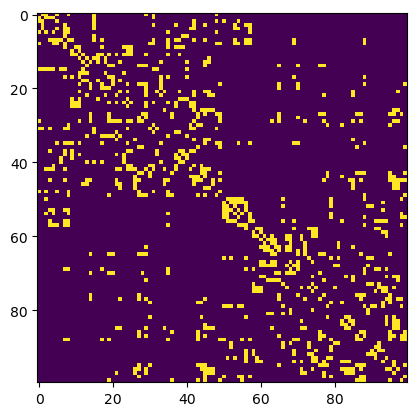

In [43]:
# plt.imshow(distance_matrix, cmap='viridis')
plt.imshow(connectomes_binarized[8], cmap='viridis')

In [ ]:
# # CHANGE THE SETUP FUNCTION!! (Is quite unprofessional - it was previously created to allow easy work in notebooks)

# """
# Connectome Preprocessing Pipeline.

# This script includes the following steps: 
#     - Computes distance matrix
#     - Loads individual connectomes, thresholds them at specified goal densities (a hyperparameter - can be passed with --goal-densities 1 2 3 ...) 
#     - Computes graph measures (if analyzing a single density, use --analyze-density 10) 
#     - Loads ROI identifiers
#     - Builds structural consensus connectomes
#     - Optionally plots/saves illustrative figures


# Usage examples: 
#     - Run end-to-end with default settings (multiple densities): 
#         python connectome_preprocessing_pipeline.py
        
#     - Run with a single density (hyperparameter) and disable plotting:
#         python connectome_preprocessing_pipeline.py --goal-densities 14 --no-plots
        
#     - Change resolution and choose which density to analyze for graph measures:
#         python connectome_preprocessing_pipeline.py \
#           --resolution 68 \
#           --goal-densities 10 12 14 16 18 20 \
#           --analyze-density 12


# Notes: 
#     - (Based on 01_preprocessing.ipynb)
#     - Paths are taken from `notebook_setup.setup()`. 
#     - Heavy intermediate results are cached to disk to avoid recomputation.  
# """


# from __future__ import annotations

# import argparse
# import sys
# import json
# from dataclasses import dataclass
# from pathlib import Path
# from typing import Iterable, List, Tuple, Optional

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from pathlib import Path

# import bct
# from netneurotools.networks import threshold_network, struct_consensus
# from scipy.spatial.distance import cdist



# import networkx as nx
# import numpy as np
# from scipy.spatial.distance import pdist, squareform

# import networkx as nx
# import numpy as np

# # Local imports from your codebase
# # from notebook_setup import setup
# from preprocessing.get_distance_matrix import get_distance_matrix_from_coords, get_distance_matrix_from_fiber_lengths
# from analysis.structural_measures import analyze_connectomes

# from src.preprocessing.preprocessing_setup import setup
# from preprocessing.threshold_to_density import threshold_to_density


# from src.preprocessing.utils import setup_paths, ensure_dir, save_numpy, save_dataframe # TODO: Remove this again, not needed. 
# # ----------------------------
# # Config & argument parsing
# # ----------------------------
# @dataclass
# class PipelineConfig:
#     resolution: int = 68
#     goal_densities: Tuple[int, ...] = (10, 12, 14, 16, 18, 20)  # in percent
#     analyze_density: int = 10  # used for steps requiring a single binarized set
#     do_plots: bool = False # True

#     # Communication model and rich-club options for graph measures
#     comm_mode: str = "estrada_scaled"
#     rich_nodes_global: Optional[np.ndarray] = None
#     rich_top_percent: float = 0.20



# def parse_args() -> PipelineConfig:
#     p = argparse.ArgumentParser(description="Connectome preprocessing pipeline")
    
#     TARGET_TOTAL_NUMBER_OF_NODES = 50 # CHANGE THIS HERE
        
#     p.add_argument("--resolution", type=int, default=TARGET_TOTAL_NUMBER_OF_NODES, # CHANGE here
#                    help="Parcellation resolution for distance matrix & inputs (default: 68)")
#     p.add_argument("--goal-densities", type=int, nargs="+",
#                    default=[10, 12, 14, 16, 18, 20],
#                    help="One or more goal densities in PERCENT to retain during thresholding")
#     p.add_argument("--analyze-density", type=int, default=10,
#                    help="Which density (in percent) to use for analyses that require a single binarized set")
#     p.add_argument("--do_plots", action="store_true",
#                    help="Activate plotting (only save data)")
#     p.add_argument("--comm-mode", type=str, default="estrada_scaled",
#                    help="Communication model used in analyze_connectomes (default: estrada_scaled)")
#     p.add_argument("--rich-top-percent", type=float, default=0.20,
#                    help="Top fraction for rich club node selection (default: 0.20)")

#     args = p.parse_args()

#     return PipelineConfig(
#         resolution=args.resolution,
#         goal_densities=tuple(args.goal_densities),
#         analyze_density=args.analyze_density,
#         do_plots=args.do_plots,
#         comm_mode=args.comm_mode,
#         rich_top_percent=args.rich_top_percent,
#     )

# # def main(resolution = None):
# # cfg = parse_args()

# cfg = PipelineConfig(
#         resolution=50, # args.resolution, # CHANGE THIS HERE ?
#         goal_densities=[10], # tuple(args.goal_densities),
#         analyze_density=10, # args.analyze_density,
#         do_plots=True, # args.do_plots,
#         comm_mode="estrada_scaled", # args.comm_mode,
#         rich_top_percent=0.2) 


# paths = setup_paths(dataset_name="suarez_MaMI_dataset") 



# # Setup paths
# base_path = paths["path_raw_data"] / "connectivity/mami"
# conn_dir = base_path / "conn_100"
# coords_dir = base_path / "coords"

# resolution = 50 # final resolution (if this is 100 <-> 50 nodes PER SIDE)

# # Intermediate paths 
# output_conn_dir = paths["path_00_preprocessed"] / f"connectomes_downsampled_to_{resolution}" # per SIDE -> so a total of 100. 
# output_coords_dir = paths["path_00_preprocessed"] / f"coords_downsampled_to_{resolution}"
# output_results_dir = paths["path_output_for_logs_and_plots"] / "results"
# output_distance_matr_resampled_dir = paths["path_00_preprocessed"] / f"dis_matrices_downsampled_to_{resolution}" # paths["path_02_distance_matrices"] 
# output_orig_dist_dir = paths["path_00_preprocessed"] / f"dis_matrices_orig"
# output_orig_conn_dir = paths["path_00_preprocessed"] / f"connectomes_orig"

# # Create output directories
# output_conn_dir.mkdir(exist_ok=True)
# output_coords_dir.mkdir(exist_ok=True)
# output_results_dir.mkdir(exist_ok=True)
# output_distance_matr_resampled_dir.mkdir(exist_ok=True)
# output_orig_dist_dir.mkdir(exist_ok=True)
# output_orig_conn_dir.mkdir(exist_ok=True)

# # Get all animal names
# animal_files = list(conn_dir.glob("*.npy"))
# animal_names = [f.stem for f in animal_files] # [:5]

# # Modified section for the MaMI preprocessing script
# # Replace the animal processing loop with this version

# # Storage for binarized connectomes at each density
# all_bin_by_density = {density: [] for density in cfg.goal_densities}

# # Storage for combined arrays and all results
# all_conn_downsampled = []
# all_dist_downsampled = []
# all_results = []

# all_orig_conn = [] 
# all_orig_dist_matr = []

# # Process each animal
# for name in animal_names:
#     print(f"Processing {name}...")
    
#     # Load data
#     connection_matrix = np.load(conn_dir / f"{name}.npy")
#     coordinates = np.load(coords_dir / f"{name}.npy")
    
#     original_distance_matrix = cdist(coordinates, coordinates)
#     np.fill_diagonal(original_distance_matrix, 0) # np.inf)
    
#     # Reduce resolution
#     # new_matrix, new_coords, orig_dist_matrx = reduce_nodes(connection_matrix, coordinates, resolution=resolution)
#     connectome_downsampled, new_coordinates, new_distance_matrix = merge_paired_nodes(coordinates=coordinates, 
#                                                                      connectome=connection_matrix)
#     # Append orig data 
#     all_orig_conn.append(connection_matrix)
#     all_orig_dist_matr.append(original_distance_matrix)
    
#     np.fill_diagonal(original_distance_matrix, 0) #  np.inf)
    
#     # Save individual files
#     np.fill_diagonal(connection_matrix, 0)
#     np.save(output_orig_conn_dir / f"{name}.npy", connection_matrix)
#     np.fill_diagonal(original_distance_matrix, 0)
#     np.save(output_orig_dist_dir / f"{name}.npy", original_distance_matrix)
#     np.fill_diagonal(connectome_downsampled, 0)
#     np.save(output_conn_dir / f"{name}.npy", connectome_downsampled)
#     np.fill_diagonal(new_distance_matrix, 0)
#     np.save(output_distance_matr_resampled_dir / f"{name}.npy", new_distance_matrix)
    
#     np.save(output_coords_dir / f"{name}.npy", new_coordinates)
        
#     # Create binarized versions at different densities
#     print(f"  Creating binarized versions:")
#     for density in cfg.goal_densities:
#         # Create temporary output folder for this density if needed
#         temp_output = paths["path_00_preprocessed"] / f"temp_bin_{density}"
#         temp_output.mkdir(exist_ok=True)
        
#         # Use your existing function
#         thres_conn, final_density = threshold_to_density(
#             conn_wei=connectome_downsampled, # connection_matrix, 
#             # n_nodes=resolution, 
#             density=density, 
#             output_folder=temp_output, 
#             conn_type="connectomes_resampled"
#         )
        
#         # Store for later combination
#         all_bin_by_density[density].append(thres_conn)
    
#     # Analyze weighted connectome
#     results = analyze_connectomes(
#         connectome_downsampled[np.newaxis, :, :],
#         new_distance_matrix,
#         comm_mode="estrada_scaled"
#     )
    
#     # Add animal name to results
#     for result in results:
#         result['animal'] = name
#         all_results.append(result)
    
#     # Store for combined arrays
#     all_conn_downsampled.append(connectome_downsampled)
#     all_dist_downsampled.append(new_distance_matrix)

# # Save combined weighted arrays
# all_conn_downsampled = np.stack(all_conn_downsampled)  # Shape: (num_animals, 100, 100)
# all_dist_downsampled = np.stack(all_dist_downsampled)  # Shape: (num_animals, 100, 100)

# all_orig_dist_matr = np.stack(all_orig_dist_matr)
# all_orig_conn = np.stack(all_orig_conn)

# np.save(paths["path_01_connectomes"] / f"00_connectomes_{resolution}.npy", all_conn_downsampled)
# np.save(paths["path_02_distance_matrices"] / f"distance_matrix_{resolution}.npy", all_dist_downsampled)

# np.save(paths["path_01_connectomes"] / f"00_connectomes_orig.npy", all_orig_conn)
# np.save(paths["path_02_distance_matrices"] / f"distance_matrix_orig.npy", all_orig_dist_matr)

# # Save combined binarized arrays for each density
# print("\nSaving combined binarized arrays...")
# for density in cfg.goal_densities:
#     all_bin = np.stack(all_bin_by_density[density])  # Shape: (num_animals, 100, 100)
    
#     save_path = paths["path_01_connectomes"] / f"01_consensus_bin_density_{density}_percent_{resolution}.npy"
#     np.save(save_path, all_bin)
#     print(f"  Density {density}%: {all_bin.shape}")
    
#     # Clean up temporary files
#     temp_output = paths["path_00_preprocessed"] / f"temp_bin_{density}"
#     if temp_output.exists():
#         for file in temp_output.glob("*.npy"):
#             file.unlink()
#         temp_output.rmdir()

# # Optionally: Analyze binarized connectomes at the specified density
# if cfg.analyze_density in cfg.goal_densities:
#     print(f"\nAnalyzing binarized connectomes at {cfg.analyze_density}% density...")
#     bin_results = []
#     all_bin_analyze = all_bin_by_density[cfg.analyze_density]
    
#     for idx, (name, bin_conn) in enumerate(zip(animal_names, all_bin_analyze)):
#         results = analyze_connectomes(
#             np.array([bin_conn]),  # Shape: (1, 100, 100)
#             all_dist_downsampled[idx],
#             comm_mode="estrada_scaled"
#         )
#         for result in results:
#             result['animal'] = name
#             bin_results.append(result)
    
#     # Save binary analysis results
#     bin_results_df = pd.DataFrame(bin_results)
#     bin_results_df.to_csv(
#         paths["path_03_graph_measures"] / f"df_graph_measures_bin_{resolution}_density_{cfg.analyze_density}_percent.csv", 
#         index=False
#     )
#     print(f"Binary analysis results saved: {bin_results_df.shape}")

# # Save weighted results as CSV (existing code)
# results_df = pd.DataFrame(all_results)
# results_df.to_csv(paths["path_03_graph_measures"] / f"df_graph_measures_{resolution}.csv", index=False)


# # Save enriched dataframe
# enriched_names_df.to_csv(
#     paths["path_04_further_info"] / f"names_of_animals_with_preprocessed_connectomes_{resolution}.csv",
#     index=True
# )

# print(f"\nProcessed {len(animal_names)} animals")
# print(f"Combined connectivity shape: {all_conn_downsampled.shape}")
# print(f"Combined distances shape: {all_dist_downsampled.shape}")
# print(f"Binarized versions created for densities: {list(cfg.goal_densities)}")
# print(f"Results saved to: {paths['path_03_graph_measures']}")